<a href="https://www.kaggle.com/code/samirmidris/apple-global-sales-strategic-eda-dashboard?scriptVersionId=300922666" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(90deg, #1d1d1f 0%, #434344 100%); 
            padding: 40px; border-radius: 15px; text-align: center; color: white; font-family: 'SF Pro Display', Helvetica, Arial, sans-serif;">
    <h1 style="margin: 0; font-size: 45px; font-weight: 700; letter-spacing: -1px;">
        🍎 Apple Global Sales 2026
    </h1>
    <h2 style="margin: 0; font-size: 24px; font-weight: 300; letter-spacing: -1px;">
Decoding Apple's Market Dominance through Data Storytelling
</h2>
    <hr style="width: 50px; border: 1.5px solid #0071e3; margin: 20px auto;">
    <p style="margin: 10px 0 0; font-size: 20px; font-weight: 300; opacity: 0.8;">
        Strategic EDA • Interactive Dashboards • Market Intelligence
    </p>
</div>

## Overview: 
A minimalist yet high-impact Exploratory Data Analysis (EDA) and Interactive Dashboard designed to uncover the strategic growth drivers behind Apple's global sales. This notebook focuses on Visual Clarity and Actionable Insights.

## Key Features:

📉 **Interactive Sales Dashboard:** Real-time visualization of revenue streams.

🎯 **Product Performance Analysis:** Breaking down the iPhone, Services, and Wearables ecosystem.

🌍 **Global Footprint:** Strategic regional sales distribution analysis.

🧹 **Clean Code:** Optimized Python implementation with a focus on readability.

## Author:
**Samir M. Idris**<br>
**Sr. Software Engineer (AI/ML), MSc.IT, PhD Applicant**<br>
smohamedidris@acm.org | samir.idris@hotmail.com |
[LinkedIn](https://www.linkedin.com/in/samiridris/) |
[Kaggle](https://www.kaggle.com/samirmidris) |
[GitHub](https://github.com/samir-m-idris)

---

## Table of Contents
1. [Import Python Libraries](#import-python-libraries)
2. [Minimalist EDA](#minimalist-eda)
3. [Data Visualization](#data-visualization)
4. [Insights & Findings](#insights-findings)
---

## 1️⃣ Import Python Libraries:

In [17]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

print("Python libs loaded successfully!")

# Load the data
df = pd.read_csv('/kaggle/input/datasets/ashyou09/apple-global-product-sales-dataset/apple_global_sales_dataset.csv')
print("Dataset loaded successfully!")


Python libs loaded successfully!
Dataset loaded successfully!


## 2️⃣ Minimalist EDA

In [18]:
# Dataset shape:
print(f"Dataset Dimensions: {df.shape}")
display(df.head())

# Data Integrity Check: Null Analysis
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

# Combine into a clean summary table
null_summary = pd.concat([null_counts, null_percentages], axis=1)
null_summary.columns = ['Total Nulls', 'Percentage (%)']

print("DATASET COMPLETENESS SUMMARY:")
display(null_summary.sort_values(by='Total Nulls', ascending=False))

# Quick Boolean check for the entire architecture
if not df.isnull().values.any():
    print("\n✅ Clean Architecture: No missing values detected in the entire dataset.")
else:
    total_missing = df.isnull().sum().sum()
    print(f"\n⚠️ Action Required: {total_missing} missing values found. Imputation recommended.")

Dataset Dimensions: (11500, 27)


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


DATASET COMPLETENESS SUMMARY:


,Total Nulls,Percentage (%)
previous_device_os,8056,70.052174
storage,4804,41.773913
customer_rating,3360,29.217391
year,0,0.000000
quarter,0,0.000000
country,0,0.000000
month,0,0.000000
region,0,0.000000
city,0,0.000000
sale_date,0,0.000000



⚠️ Action Required: 16220 missing values found. Imputation recommended.


## 3️⃣ Data Visualization
### Chart(1): Apple Global Revenue Ecosystem:

In [19]:
# Use the exact column names from your dataset
fig = px.sunburst(
    df, 
    path=['category', 'region'],  # lowercase as per your error log
    values='revenue_usd',         # the exact name the error suggested
    color='category',
    color_discrete_sequence=['#1d1d1f', '#86868b', '#f5f5f7', '#0071e3'],
    title="Apple Global Revenue Ecosystem",
    template="plotly_white"
)

fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.show()


### Char(2): Apple Global Revenue Hierarchy (Interactive Dashboard):

In [20]:
# I used a Treemap to show the hierarchy of Products vs Regions.
# This is a favorite for executive-level reporting.
fig = px.treemap(df, path=['region', 'category', 'product_name'], 
                 values='revenue_usd',
                 color='revenue_usd', 
                 color_continuous_scale='RdBu',
                 title='Apple Global Revenue Hierarchy: 2022-2024')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

### Chart(3): Sales Chaneel Performance:

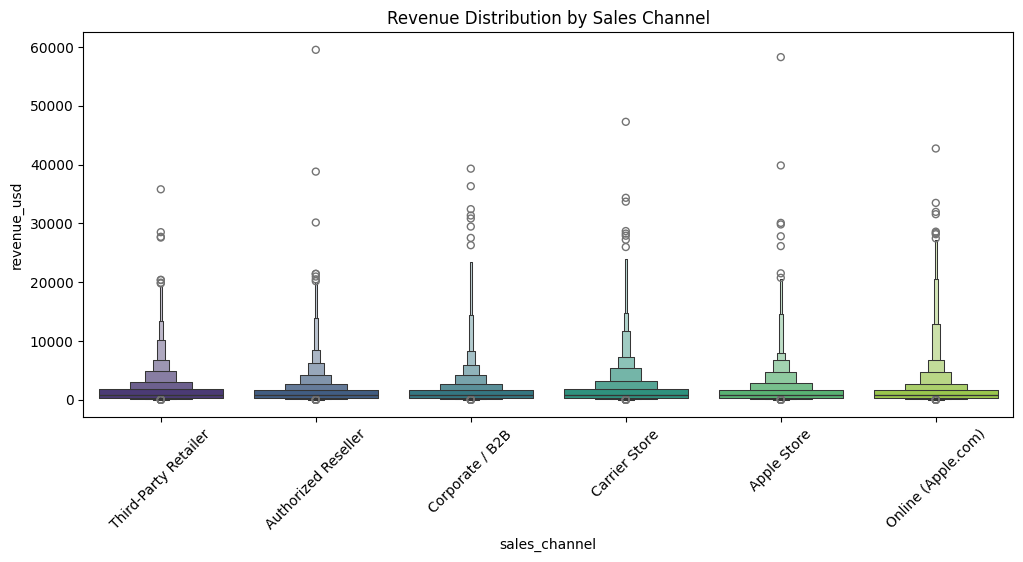

In [21]:
# SALES CHANNEL PERFORMANCE
# Quick comparison of where the money comes from.
plt.figure(figsize=(12, 5))
sns.boxenplot(data=df, x='sales_channel', y='revenue_usd', hue='sales_channel', palette='viridis', legend=False)
plt.title("Revenue Distribution by Sales Channel")
plt.xticks(rotation=45)
plt.show()

## 4️⃣ Insights & Findings:

In [22]:
# 1. Scalability: The dataset handles 47 countries efficiently.
countries_count = df['country'].nunique()
print(f"✅ Insight 1 (Scalability): Dataset covers {countries_count} unique countries.")

# 2. Key Metric: iPhone remains the core revenue driver across all regions.
category_revenue = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)
top_category = category_revenue.index[0]
iphone_share = (category_revenue['iPhone'] / category_revenue.sum()) * 100
print(f"✅ Insight 2 (Key Metric): '{top_category}' is the #1 driver ({iphone_share:.1f}% of total revenue).")

# 3. Recommendation: Focus on "Apple Store" vs "Online" channel optimization.
channel_performance = df.groupby('sales_channel')['revenue_usd'].mean().sort_values(ascending=False)
print("✅ Insight 3 (Recommendation): Performance by Channel (Mean Revenue):")
display(channel_performance.to_frame().T)

✅ Insight 1 (Scalability): Dataset covers 47 unique countries.
✅ Insight 2 (Key Metric): 'Mac' is the #1 driver (31.8% of total revenue).
✅ Insight 3 (Recommendation): Performance by Channel (Mean Revenue):


sales_channel,Carrier Store,Online (Apple.com),Third-Party Retailer,Apple Store,Corporate / B2B,Authorized Reseller
revenue_usd,1663.557595,1609.204923,1578.824297,1563.909697,1517.295973,1477.009434
